# Hydrodynamic comparison plots

Compares **Added mass** and **Radiation damping** across multiple OrcaWave/OrcaFlex
exports, for the **Heave, Pitch and Roll** degrees of freedom (in that order).

Each subplot shows **one line per Excel file** so the configurations can be
compared directly. Set the file paths and the display names you want in the
legend in the configuration cell below.

## Imports and settings

In [15]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
%matplotlib inline

# Larger, clearer text everywhere
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,
    "axes.labelsize": 17,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 15,
    "figure.titlesize": 24,
})

# =========================================================================
#  EDIT HERE
#  ---------
#  Map each Excel file to the name you want to see in the legend.
#  Order = drawing/legend order. Add or remove entries as you like.
# =========================================================================
DATASETS = {
    "Harlequin_DAresults_fixed.xlsx":     "Harlequin fixed",
    "Harlequin_DAresults_spring.xlsx":    "Harlequin spring",
    "Merganser_final_compensated.xlsx":   "Merganser",
}

# One colour per dataset (cycled if you add more than there are colours).
COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]

# Degrees of freedom to plot, in the requested order.
# Values are the 0-based DOF index in the file (Surge=0 ... Yaw=5).
DOFS = [("Heave", 2), ("Pitch", 4), ("Roll", 3)]

## Reading the data

**Added mass / Damping** are stored as blocks: one 6x6 DOF matrix per period.
Each block starts with a marker (`... for period X,Ys`) in column 1; the matrix
begins 5 rows below it. We take the diagonal terms (the direct added mass /
damping for each own degree of freedom).

In [16]:
def read_matrix_sheet(xlsx, sheet):
    """Read 'Added mass'/'Damping' from one file. Returns (periods, diag[n, 6])."""
    df = pd.read_excel(xlsx, sheet_name=sheet, header=None)

    periods, diag = [], []
    for i in range(df.shape[0]):
        marker = df.iat[i, 1] if df.shape[1] > 1 else None
        if isinstance(marker, str) and "period" in marker.lower():
            txt = marker.lower().split("period")[-1].replace("s", "").strip()
            period = float(txt.replace(",", "."))          # NL comma -> dot
            block = df.iloc[i + 5 : i + 11, 1:7].to_numpy(dtype=float)
            periods.append(period)
            diag.append(np.diag(block))

    order = np.argsort(periods)
    return np.array(periods)[order], np.array(diag)[order]

## Plot helper

In [20]:
def plot_matrix_compare(sheet, title, ylabel1, ylabel2):
    """One figure, 3 subplots (Heave/Pitch/Roll), one line per dataset."""
    # Read every dataset once.
    series = {}
    for path, name in DATASETS.items():
        periods, diag = read_matrix_sheet(path, sheet)
        series[name] = (periods, diag)

    fig, axes = plt.subplots(1, len(DOFS), figsize=(18, 6))
    for ax, (dof_name, idx) in zip(axes, DOFS):
        for c, (name, (periods, diag)) in zip(COLORS, series.items()):
            ax.plot(periods, diag[:, idx], lw=2.2, color=c, label=name)
        ax.set_title(dof_name, fontweight="bold")
        ax.set_xlabel("Period [s]")
        ax.set_ylabel(ylabel1 if ax == axes[0] else ylabel2)
        ax.grid(True, alpha=0.3)
        ax.tick_params(width=1.2, length=6)
        ax.legend()
    fig.suptitle(title, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    return fig

## 1. Added mass vs period

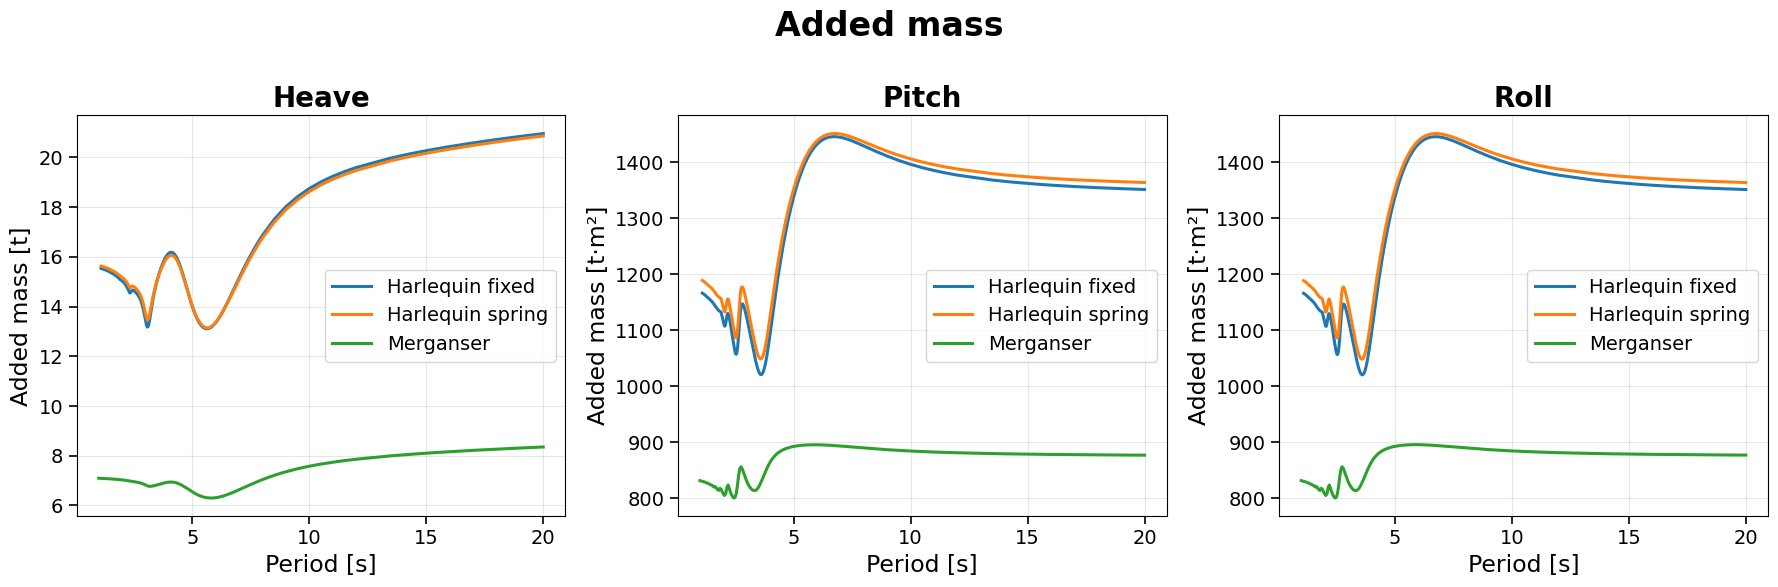

In [21]:
fig = plot_matrix_compare(
    "Added mass",
    "Added mass",
    "Added mass [t]",
    "Added mass [t·m²]",
)
fig.savefig("1_added_mass.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Radiation damping vs period

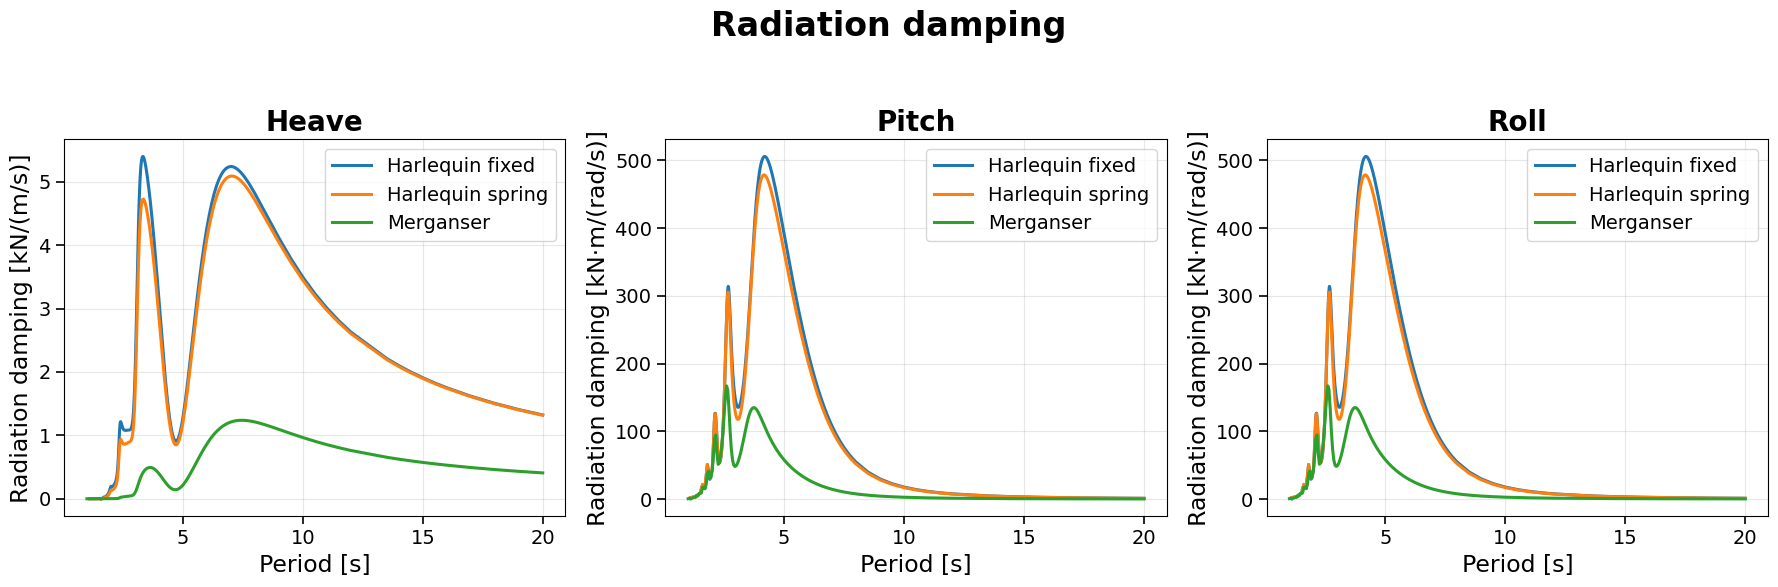

In [19]:
fig = plot_matrix_compare(
    "Damping",
    "Radiation damping",
    "Radiation damping [kN/(m/s)]",
    "Radiation damping [kN·m/(rad/s)]",
)
fig.savefig("2_damping.png", dpi=150, bbox_inches="tight")
plt.show()